# NEB Barrier Evolution
This code plots the evolution of the calculated energies of each image over each NEB iteration.
Based on code by Shreedhar Todi.

In [1]:
# Import relevant packages/libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import os
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from ase.atoms import Atoms
from ase.visualize import view

In [2]:
# Define parameters
basename = "4-11a"
work_dir = f"./{basename}/"
num_images = 15

# Get energies from range of iterations
start_iteration = 0
end_iteration = 73

# Plot settings
save_figures = False
figure_format = "svg"  # svg, png, pdf

In [3]:
def get_energies(filepath, basename, num_images, iteration):
    """
    Go through each PW.out file in filepath and extract the final calculated energy.
    """
    temp_energies = []
    energies = []
    
    for i in range(1, num_images + 1):
        pw_out_path = os.path.join(filepath, basename + f"_{i}/PW.out")
        with open(pw_out_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            if line.strip().startswith("!    total energy"):
                energy = float(line.split()[4])
                temp_energies.append(energy)
        energies.append(temp_energies[iteration])
                
    return energies

def get_all_energies(filepath, basename, num_images):
    """
    Go through each PW.out file in filepath and extract all calculated energies.
    Returns array of shape (num_iterations, num_images) for easy iteration-based plotting.
    """
    # First, collect all energies for each image as lists
    energies_per_image = []
    
    for i in range(1, num_images + 1):
        pw_out_path = os.path.join(filepath, basename + f"_{i}/PW.out")
        image_energies = []
        with open(pw_out_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            if line.strip().startswith("!    total energy"):
                energy = float(line.split()[4])
                image_energies.append(energy)
        energies_per_image.append(image_energies)
    
    # Use max iterations across all images (some may have more SCF steps than others)
    num_iterations = max(len(e) for e in energies_per_image)

    # Create array of shape (num_iterations, num_images)
    all_energies = np.zeros((num_iterations, num_images))
    for img_idx, image_energies in enumerate(energies_per_image):
        for iter_idx, energy in enumerate(image_energies):
            all_energies[iter_idx, img_idx] = energy
    
    return all_energies
    

## Plot 1: Final NEB Energy Profile
This plot shows the energy profile along the reaction coordinate from the final NEB calculation.

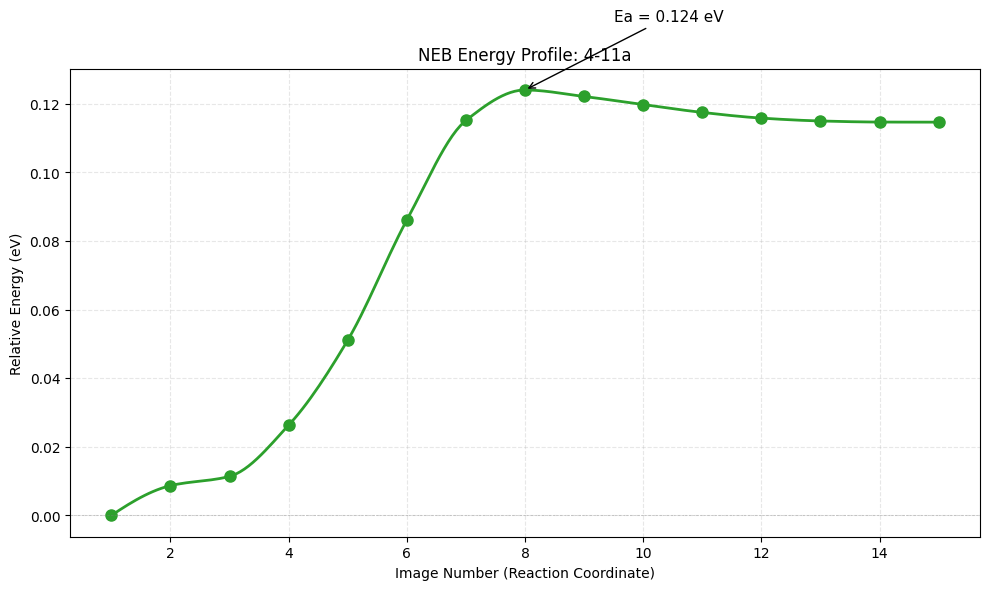


NEB ENERGY PROFILE SUMMARY
System: 4-11a
Number of images: 15
Forward activation energy: 0.1240 eV
Reverse activation energy: 0.0094 eV
Reaction energy (ΔE): 0.1147 eV


In [4]:
# Get energies from PW.out files
all_energies = np.array(get_energies(work_dir, basename, num_images, -1))

# Convert to relative energies (relative to first image)
relative_energies = all_energies - all_energies[0]

# Image numbers (reaction coordinate)
x = np.arange(1, num_images + 1)

# Create smooth x-axis for interpolation
x_dense = np.linspace(1, num_images, 200)

# Plot the energy profile
fig, ax = plt.subplots(figsize=(10, 6))

# Smooth interpolation
interp = PchipInterpolator(x, relative_energies)
y_smooth = interp(x_dense)

# Plot smooth line and markers
ax.plot(x_dense, y_smooth, color='#2ca02c', linewidth=2, label='Energy Profile')
ax.plot(x, relative_energies, 'o', markersize=8, color='#2ca02c')

# Find and annotate the transition state (maximum energy)
max_idx = np.argmax(relative_energies)
barrier = relative_energies[max_idx]
ax.annotate(f'Ea = {barrier:.3f} eV', 
            xy=(x[max_idx], barrier),
            xytext=(x[max_idx] + 1.5, barrier + 0.02),
            fontsize=11, ha='left',
            arrowprops=dict(arrowstyle='->', color='black', lw=1))

ax.set_xlabel("Image Number (Reaction Coordinate)")
ax.set_ylabel("Relative Energy (eV)")
ax.set_title(f"NEB Energy Profile: {basename}")

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

if save_figures:
    fig.savefig(f"{basename}_energy_profile.{figure_format}", 
                format=figure_format, dpi=300, bbox_inches="tight", transparent=True)
    print(f"Saved: {basename}_energy_profile.{figure_format}")

plt.show()

# Print summary
print("\n" + "="*50)
print("NEB ENERGY PROFILE SUMMARY")
print("="*50)
print(f"System: {basename}")
print(f"Number of images: {num_images}")
print(f"Forward activation energy: {barrier:.4f} eV")
print(f"Reverse activation energy: {barrier - relative_energies[-1]:.4f} eV")
print(f"Reaction energy (ΔE): {relative_energies[-1]:.4f} eV")

# Plot 2: Energy Profile Changes
Now we plot how the energy curve changes over each iteration.

In [5]:
# Initialize lists to store energies
all_energies = get_all_energies(work_dir, basename, num_images)
all_energies = np.array(all_energies)
print(all_energies)


[[-8971.93911576 -8971.90567381 -8971.81734561 ... -8971.70147124
  -8971.78480988 -8971.82445172]
 [-8971.93911576 -8971.90833536 -8971.82595736 ... -8971.75129537
  -8971.80915884 -8971.82445173]
 [-8971.93911576 -8971.91173942 -8971.83780907 ... -8971.80343607
  -8971.82336908 -8971.82445173]
 ...
 [-8971.93911576 -8971.93046224 -8971.92769929 ... -8971.82411131
  -8971.82442463 -8971.82445372]
 [-8971.93911576 -8971.93044939 -8971.92770713 ... -8971.82411126
  -8971.8244246  -8971.82445375]
 [-8971.93911576 -8971.93042566 -8971.92771087 ... -8971.82411109
  -8971.82442454 -8971.82445381]]


/tmp/ipykernel_1389862/567512998.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


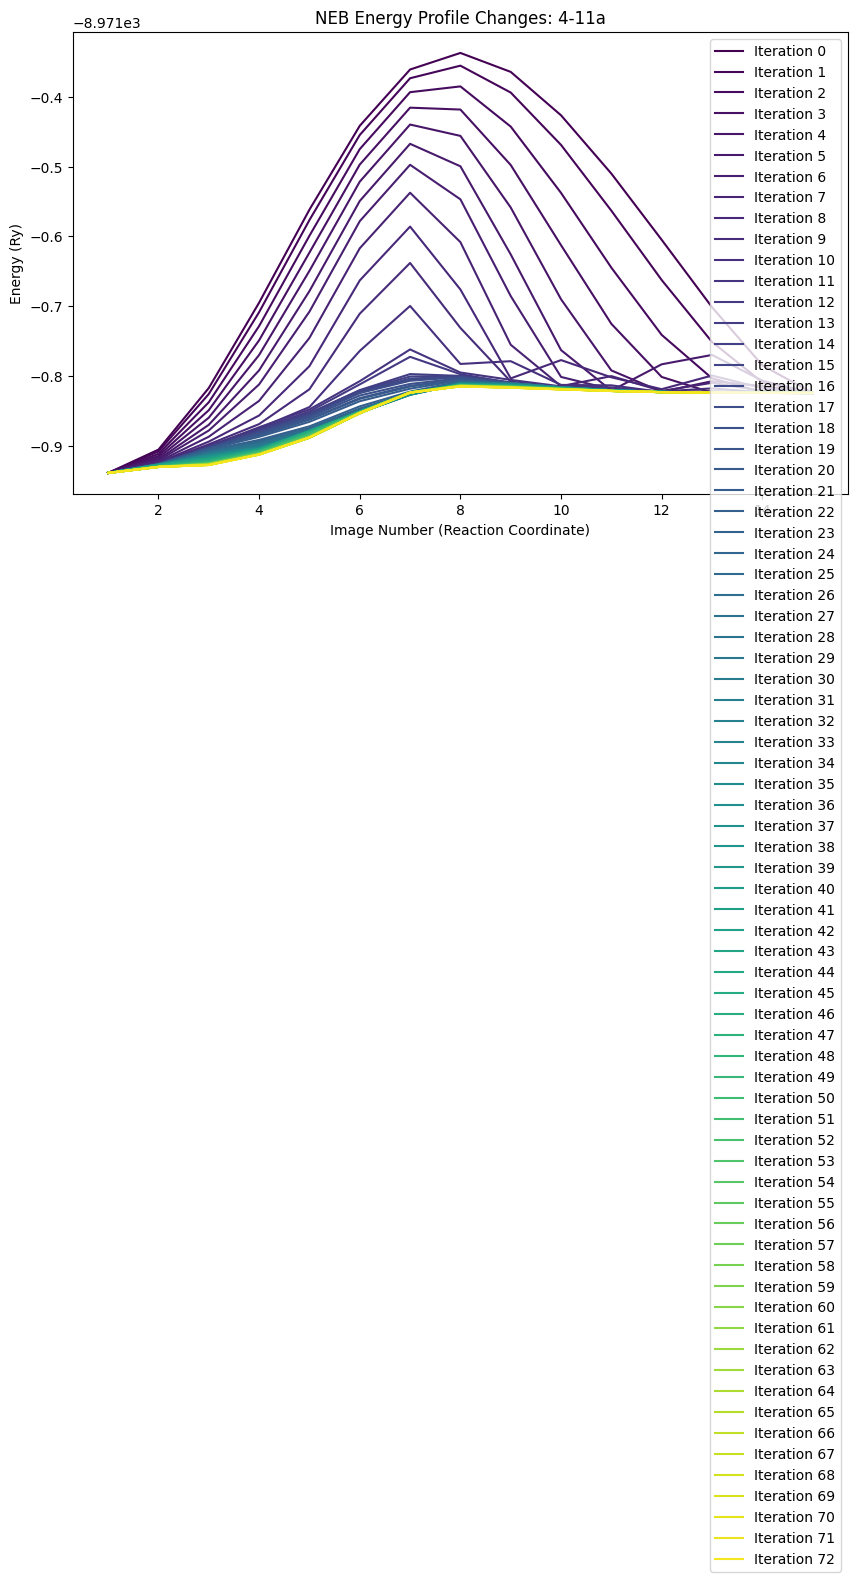

In [6]:
# Create a colormap for the iterations
cmap = plt.cm.viridis
cnorm = mcolors.Normalize(vmin=start_iteration, vmax=end_iteration)
colours = cmap(cnorm(np.arange(start_iteration, end_iteration)))

# Create a figure for the energy profile changes
fig, ax = plt.subplots(figsize=(10, 6))
for iteration in range(start_iteration, end_iteration):
    energies = all_energies[iteration]
    ax.plot(x, energies, label=f'Iteration {iteration}', color=colours[iteration - start_iteration])

ax.set_xlabel("Image Number (Reaction Coordinate)")
ax.set_ylabel("Energy (Ry)")
ax.set_title(f"NEB Energy Profile Changes: {basename}")
ax.legend()

plt.tight_layout()

if save_figures:
    fig.savefig(f"{basename}_energy_profile_changes.{figure_format}", 
                format=figure_format, dpi=300, bbox_inches="tight", transparent=True)
    print(f"Saved: {basename}_energy_profile_changes.{figure_format}")


# Plot 3: Atom Position Evolution

In [7]:
def extract_crd_data(basename):
    """Extract atomic coordinates from a NEB `.crd` file.

    Returns a nested list of images -> atoms -> [symbol, [x, y, z]].

    Notes
    -----
    Some `.crd` files include an extra trailing column (e.g., force multipliers 0/1).
    That column is ignored.
    """
    with open(work_dir + basename + ".crd") as f:
        contents = f.readlines()

    image_coordinates = []
    current_image = []

    for raw in contents:
        line = raw.strip()
        if not line:
            continue

        # Image markers look like: "IMAGE 1" (varies by generator)
        if "IMAGE" in line:
            if current_image:
                image_coordinates.append(current_image)
            current_image = []
            continue

        parts = line.split()

        # Atomic lines are typically: sym x y z [mult]
        if len(parts) in (4, 5):
            atom_type = parts[0]
            try:
                x, y, z = map(float, parts[1:4])
            except ValueError:
                continue
            current_image.append([atom_type, [x, y, z]])

    if current_image:
        image_coordinates.append(current_image)

    return image_coordinates


def extract_ase_atoms(basename):
    coordinates = extract_crd_data(basename)
    all_atoms = []

    # Extract unit cell once from basename.axsf
    unit_cell = None
    with open(work_dir + basename + ".axsf") as f:
        for line in f:
            if "PRIMVEC" in line:
                unit_cell = [[float(x) for x in next(f).split()] for _ in range(3)]
                break

    for image in coordinates:
        atoms_symbols = [atom[0] for atom in image]
        atoms_coordinates = [atom[1] for atom in image]
        atoms = Atoms(atoms_symbols, atoms_coordinates)

        if unit_cell is not None:
            atoms.set_cell(unit_cell)

        atoms.center()
        all_atoms.append(atoms)

    return all_atoms


In [8]:
all_atoms = extract_ase_atoms(basename)
view(all_atoms, viewer='ngl')

# View Specific Images

In [9]:
def view_specific_images(basename, image_indices):
    """
    View specific images from the NEB calculation.
    
    Args:
        basename (str): The base name of the NEB calculation.
        image_indices (list): List of image indices to view.
    """
    # Extract atomic coordinates
    coordinates = extract_crd_data(basename)
    
    # Extract specific images
    specific_images = [coordinates[i-1] for i in image_indices]
    
    # Convert to ASE Atoms objects
    atoms_list = []
    for image in specific_images:
        atoms_symbols = []
        atoms_coordinates = []
        for atom in image:
            atoms_symbols.append(atom[0])
            atoms_coordinates.append(atom[1])
        atoms = Atoms(atoms_symbols, atoms_coordinates)
        
        # Extract unit cell from basename.axsf
        with open(work_dir + basename + '.axsf') as f:
            for line in f:
                if 'PRIMVEC' in line:
                    unit_cell = []
                    for i in range(3):
                        unit_cell.append([float(x) for x in next(f).split()])
        # Add unit cell to the atoms object
        atoms.set_cell(unit_cell)
        atoms.center()
        
        atoms_list.append(atoms)
    
    # Return the list of Atoms objects
    return atoms_list



In [10]:
image_indices = [1, 4, 7, 8, 9, num_images]
specific_atoms = view_specific_images(basename, image_indices)
view(specific_atoms[0], viewer='x3d')